<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/61025FND_for_CoNV_excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from openpyxl import Workbook
from openpyxl.utils import get_column_letter

# Create workbook and active worksheet
wb = Workbook()
ws = wb.active
ws.title = "FND Research Data"

# Define the headers for FND research
headers = [
    "Patient ID",
    "Age",
    "Gender",
    "Eye Treated (Right/Left/Both)",
    "Indication for FND",
    "Date of Procedure",
    "Needle Gauge",
    "Diathermy Current Setting (mA)",
    "Duration of Current Application (seconds)",
    "Number of Vessels Treated",
    "Pre-treatment Vessel Status (Grading)",
    "Vessel Closure Success (Yes/No)",
    "Follow-up Time (days)",
    "Complications",
    "Visual Acuity Before",
    "Visual Acuity After",
    "Additional Treatments",
    "Comments / Notes"
]

# Add headers to the first row
for col_num, header in enumerate(headers, 1):
    col_letter = get_column_letter(col_num)
    ws[f"{col_letter}1"] = header

# Optionally set column widths for better readability
column_widths = [15, 5, 10, 20, 25, 15, 12, 25, 30, 20, 25, 20, 20, 30, 20, 20, 25, 40]
for i, width in enumerate(column_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = width

# Save workbook
wb.save("FND_Research_Data.xlsx")

print("Excel file 'FND_Research_Data.xlsx' created successfully.")


Excel file 'FND_Research_Data.xlsx' created successfully.


Image: Post PK bharathi.jpg
Vessel Area (%): 21.96
CNV Grade (0-4): 2


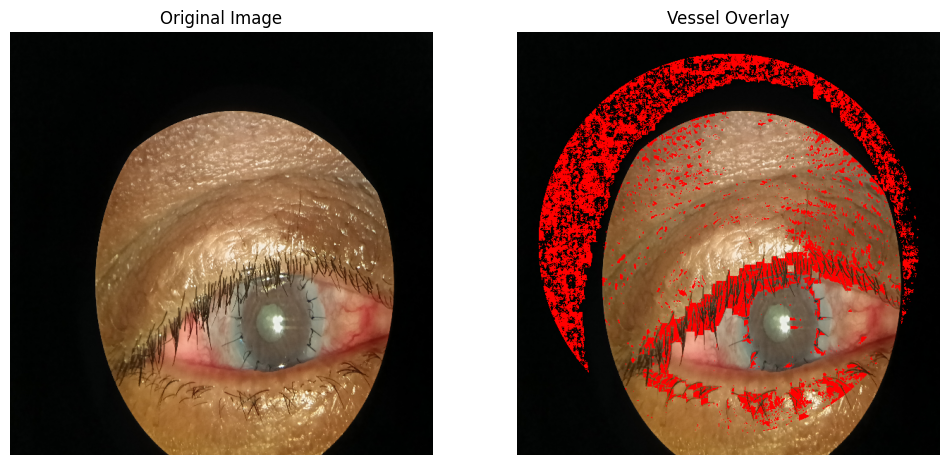

In [11]:
import cv2
import numpy as np

# Path to the single image
img_path = "/content/drive/MyDrive/Post PK bharathi.jpg"
filename = "Post PK bharathi.jpg"

# Function to assign CNV grade based on vessel area %
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# Read and resize image
img = cv2.imread(img_path)
img = cv2.resize(img, (600, 600))

# Convert to grayscale and enhance contrast
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.equalizeHist(gray)

# Apply circular mask for cornea
mask = np.zeros_like(gray)
h, w = gray.shape
cv2.circle(mask, (w//2, h//2), int(0.45*w), 255, -1)
masked = cv2.bitwise_and(gray, gray, mask=mask)

# Morphological top-hat filtering
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# Threshold to detect vessels
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# Calculate vessel area %
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# Assign CNV grade
cnv_grade = assign_cnv_grade(vessel_percent)

# Print results
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# Optional: Display original and overlay images
import matplotlib.pyplot as plt

# Create overlay: red vessels on original image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh==255] = [255, 0, 0]  # Red overlay

# Display side by side
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(overlay)
ax[1].set_title("Vessel Overlay")
ax[1].axis('off')

plt.show()


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to the single image
img_path = "/content/JPEG image 2.jpeg"
filename = "Postpk internet image.jpg"

# Function to assign CNV grade based on vessel area %
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# Read and resize image
img = cv2.imread(img_path)
img = cv2.resize(img, (600, 600))

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
gray_blur = cv2.GaussianBlur(gray, (5,5), 0)

# Enhance contrast using histogram equalization
gray_eq = cv2.equalizeHist(gray_blur)

# Apply circular mask for cornea
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w//2, h//2), int(0.45*w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# Morphological top-hat filtering
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# Threshold to detect vessels
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# Calculate vessel area %
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# Assign CNV grade
cnv_grade = assign_cnv_grade(vessel_percent)

# Print results
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# Optional: Display original and overlay images
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh==255] = [255, 0, 0]  # Red overlay

# Display side by side
fig, ax = plt.subp


Image: Postpk internet image.jpg
Vessel Area (%): 5.90
CNV Grade (0-4): 1


AttributeError: module 'matplotlib.pyplot' has no attribute 'subp'

Image: Post PK Internet Image
Vessel Area (%): 5.90
CNV Grade (0-4): 1


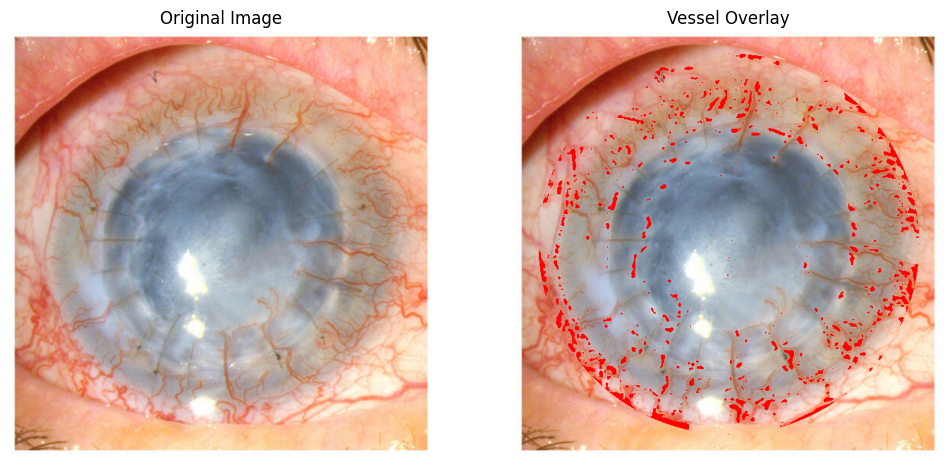

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5,5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w//2, h//2), int(0.45*w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRINT RESULTS ---
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# --- CREATE RED OVERLAY ---
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh==255] = [255, 0, 0]  # Red overlay for vessels

# --- DISPLAY ORIGINAL AND OVERLAY SIDE BY SIDE ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(overlay)
ax[1].set_title("Vessel Overlay")
ax[1].axis('off')

plt.show()


Image: Post PK Internet Image
Vessel Area (%): 5.90
CNV Grade (0-4): 1


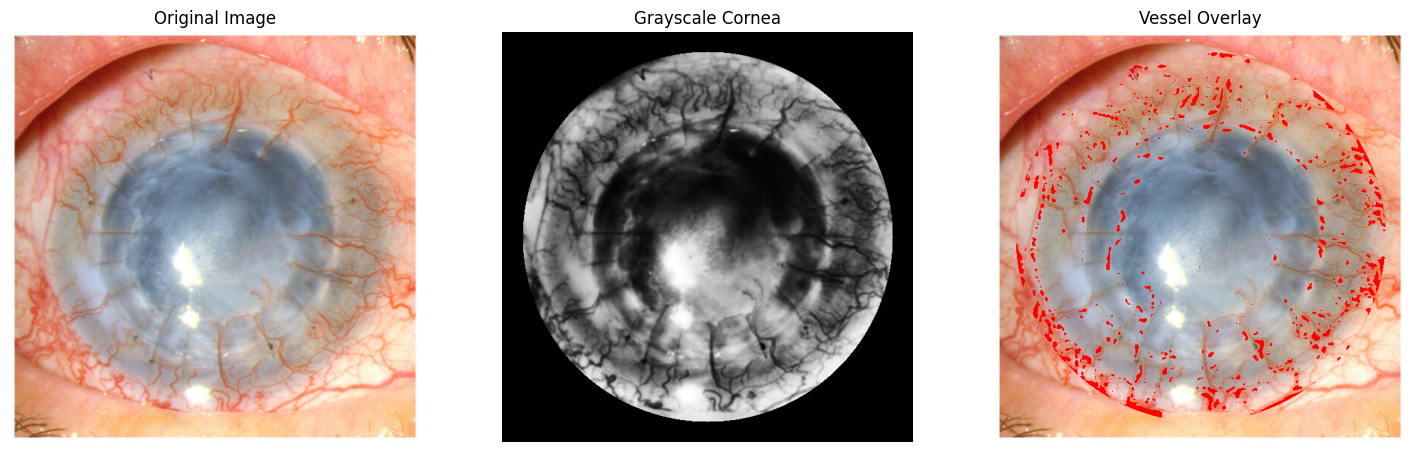

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5,5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w//2, h//2), int(0.45*w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRINT RESULTS ---
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# --- CREATE RED OVERLAY ---
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh==255] = [255, 0, 0]  # Red overlay for vessels

# --- DISPLAY ORIGINAL, GRAYSCALE, AND OVERLAY SIDE BY SIDE ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(masked, cmap='gray')
ax[1].set_title("Grayscale Cornea")
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title("Vessel Overlay")
ax[2].axis('off')

plt.show()


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5,5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w//2, h//2), int(0.45*w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRINT RESULTS ---
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# --- CREATE RED OVERLAY ON ORIGINAL IMAGE ---
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh==255] = [255, 0, 0]  # Red overlay

# --- DISPLAY ORIGINAL, VESSEL MASK, AND OVERLAY ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Vessels Only (Grayscale)")
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title("Vessel Overlay")
ax[2].axis('off


SyntaxError: unterminated string literal (detected at line 79) (ipython-input-577197936.py, line 79)

Image: Post PK Internet Image
Vessel Area (%): 5.90
CNV Grade (0-4): 1


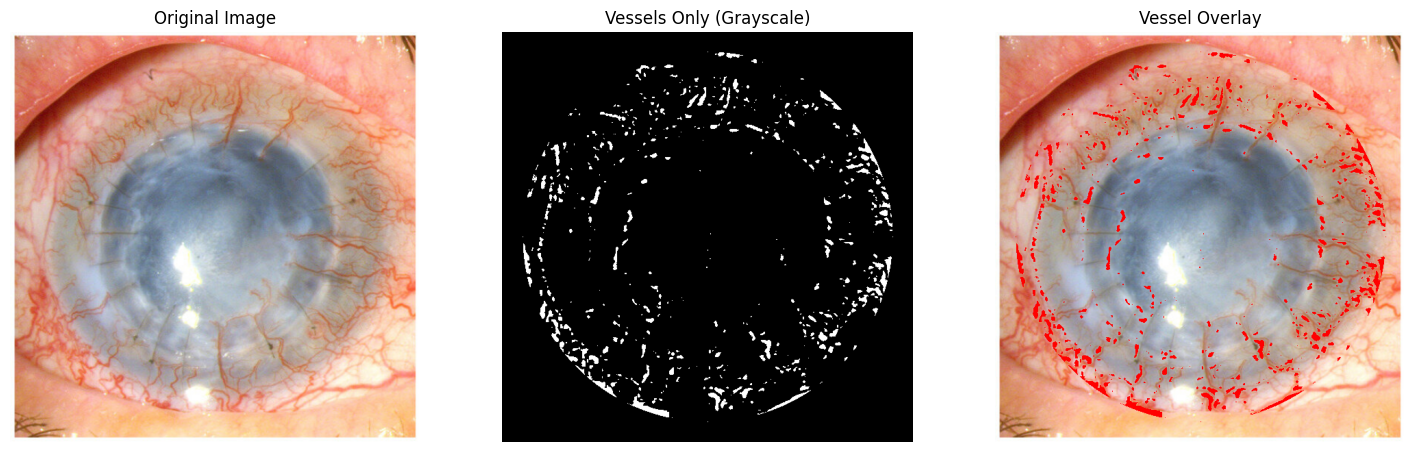

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND APPLY GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w // 2, h // 2), int(0.45 * w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRINT RESULTS ---
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# --- CREATE RED OVERLAY ON ORIGINAL IMAGE ---
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh == 255] = [255, 0, 0]  # Red overlay for vessels

# --- DISPLAY ORIGINAL, VESSEL MASK, AND OVERLAY ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Vessels Only (Grayscale)")
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title("Vessel Overlay")
ax[2].axis('off')

plt.show()


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND APPLY GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w // 2, h // 2), int(0.45 * w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRI


Image: Post PK Internet Image
Vessel Area (%): 5.90
CNV Grade (0-4): 1


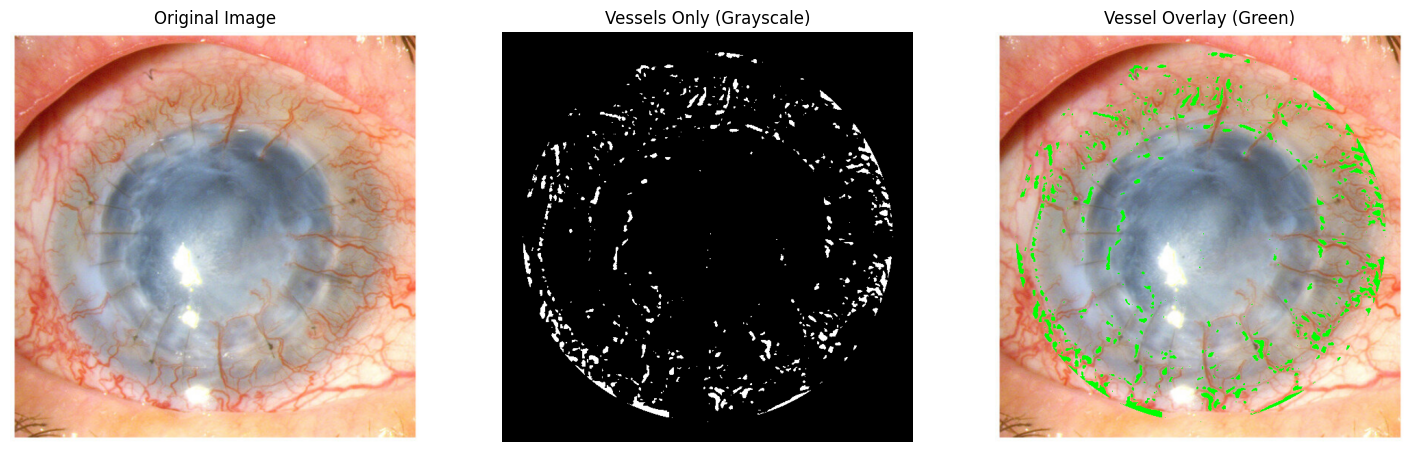

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PATH TO IMAGE ---
img_path = "/content/JPEG image 2.jpeg"
filename = "Post PK Internet Image"

# --- FUNCTION TO ASSIGN CNV GRADE ---
def assign_cnv_grade(vessel_percent):
    if vessel_percent == 0:
        return 0
    elif vessel_percent <= 10:
        return 1
    elif vessel_percent <= 25:
        return 2
    elif vessel_percent <= 50:
        return 3
    else:
        return 4

# --- READ AND RESIZE IMAGE ---
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")
img = cv2.resize(img, (600, 600))

# --- CONVERT TO GRAYSCALE AND APPLY GAUSSIAN BLUR ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# --- CONTRAST ENHANCEMENT ---
gray_eq = cv2.equalizeHist(gray_blur)

# --- CIRCULAR MASK FOR CORNEA ---
mask = np.zeros_like(gray_eq)
h, w = gray_eq.shape
cv2.circle(mask, (w // 2, h // 2), int(0.45 * w), 255, -1)
masked = cv2.bitwise_and(gray_eq, gray_eq, mask=mask)

# --- MORPHOLOGICAL TOP-HAT FILTERING ---
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
tophat = cv2.morphologyEx(masked, cv2.MORPH_TOPHAT, kernel)

# --- THRESHOLDING TO SEGMENT VESSELS ---
_, thresh = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)

# --- CALCULATE VESSEL AREA (%) ---
vessel_pixels = np.count_nonzero(thresh)
total_pixels = np.count_nonzero(mask)
vessel_percent = (vessel_pixels / total_pixels) * 100

# --- ASSIGN CNV GRADE ---
cnv_grade = assign_cnv_grade(vessel_percent)

# --- PRINT RESULTS ---
print(f"Image: {filename}")
print(f"Vessel Area (%): {vessel_percent:.2f}")
print(f"CNV Grade (0-4): {cnv_grade}")

# --- CREATE GREEN OVERLAY ON ORIGINAL IMAGE ---
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[thresh == 255] = [0, 255, 0]  # Green overlay for vessels

# --- DISPLAY ORIGINAL, VESSEL MASK, AND OVERLAY ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Vessels Only (Grayscale)")
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title("Vessel Overlay (Green)")
ax[2].axis('off')

plt.show()
